# Lab 3 - EEG Seizure Detection and Time Trace

## Goal
In this part of the lab, we will:

1. Load the EEG file `eeg14.edf`
2. Inspect its basic properties
3. Load the three annotation files
4. Detect seizure segments for file 14
5. Plot the EEG time trace around the first seizure

## Files used
- `eeg14.edf`
- `annotations_2017_A.csv`
- `annotations_2017_B.csv`
- `annotations_2017_C.csv`

## Important note
For `eeg14.edf`, we must use **column 14** from the annotation files.  
Because Python uses zero-based indexing, **column 14 = index 13**.

In [1]:
import mne
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Step 1 - Load the EDF file

We start by loading the EEG recording and printing its basic information.

In [2]:
# Load the EDF file
raw = mne.io.read_raw_edf("eeg14.edf", preload=True)

# Print basic information
print("File loaded successfully")
print("Number of channels:", len(raw.ch_names))
print("Sampling frequency:", raw.info["sfreq"])
print("Number of samples:", raw.n_times)
print("Duration in seconds:", raw.n_times / raw.info["sfreq"])
print("Annotations:", raw.annotations)

Extracting EDF parameters from eeg14.edf...
Setting channel info structure...
Creating raw.info structure...


C:\Users\Hussein\AppData\Local\Temp\ipykernel_8824\3613932690.py:2: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf("eeg14.edf", preload=True)
C:\Users\Hussein\AppData\Local\Temp\ipykernel_8824\3613932690.py:2: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf("eeg14.edf", preload=True)


Reading 0 ... 953855  =      0.000 ...  3725.996 secs...
File loaded successfully
Number of channels: 21
Sampling frequency: 256.0
Number of samples: 953856
Duration in seconds: 3726.0
Annotations: <Annotations | 0 segments>


## Step 2 - Display channel names

This helps us understand the EEG channel layout contained in the EDF file.

In [3]:
print("Channel names:")
for ch in raw.ch_names:
    print(ch)

Channel names:
EEG Fp1-Ref
EEG Fp2-Ref
EEG F3-Ref
EEG F4-Ref
EEG F7-Ref
EEG F8-Ref
EEG Fz-Ref
EEG C3-Ref
EEG C4-Ref
EEG Cz-Ref
EEG T3-Ref
EEG T5-Ref
EEG T4-Ref
EEG T6-Ref
EEG P3-Ref
EEG P4-Ref
EEG Pz-Ref
EEG O1-Ref
EEG O2-Ref
ECG EKG
Resp Effort


## Step 3 - Load the annotation files

The EDF file does not contain seizure annotations inside `raw.annotations`, so we use the external CSV annotation files provided with the dataset.

Each annotation file contains labels for all EEG recordings:
- row 1 is not signal data; it contains file numbering
- starting from row 2, each row corresponds to one second
- value `1` means seizure
- value `0` means non-seizure

In [4]:
# Load the annotation CSV files
ann_a = pd.read_csv("annotations_2017_A.csv", header=None)
ann_b = pd.read_csv("annotations_2017_B.csv", header=None)
ann_c = pd.read_csv("annotations_2017_C.csv", header=None)

print("A shape:", ann_a.shape)
print("B shape:", ann_b.shape)
print("C shape:", ann_c.shape)

A shape: (15417, 79)
B shape: (15417, 79)
C shape: (15417, 79)


## Step 4 - Extract annotations for `eeg14`

We need column 14 from each CSV file.

Because Python uses zero-based indexing:
- file 14 corresponds to column index 13

We also skip the first row because it is not part of the per-second annotation labels.

In [5]:
# Column 14 in the dataset -> index 13 in Python
col_idx = 13

# Skip the first row, then convert values to integers
a = ann_a.iloc[1:, col_idx].fillna(0).astype(int).to_numpy()
b = ann_b.iloc[1:, col_idx].fillna(0).astype(int).to_numpy()
c = ann_c.iloc[1:, col_idx].fillna(0).astype(int).to_numpy()

print("Length of annotation A:", len(a))
print("Length of annotation B:", len(b))
print("Length of annotation C:", len(c))

Length of annotation A: 15416
Length of annotation B: 15416
Length of annotation C: 15416


## Step 5 - Build a consensus seizure label

The dataset provides annotations from three annotators:
- A
- B
- C

To get a more robust result, we use **majority voting**:

A second is considered seizure if at least **2 out of 3** annotators marked it as seizure.

In [6]:
# Majority voting consensus
consensus = ((a + b + c) >= 2).astype(int)

print("Unique values in consensus:", np.unique(consensus))

Unique values in consensus: [0 1]


## Step 6 - Detect seizure segments

Now we convert the 0/1 consensus signal into seizure intervals:

- start second
- end second
- duration

In [7]:
segments = []
in_seizure = False
start = 0

for i, val in enumerate(consensus):
    if val == 1 and not in_seizure:
        start = i
        in_seizure = True
    elif val == 0 and in_seizure:
        segments.append((start, i - 1))
        in_seizure = False

if in_seizure:
    segments.append((start, len(consensus) - 1))

print("Detected seizure segments (in seconds):")
for idx, (s, e) in enumerate(segments, 1):
    print(f"Seizure {idx}: start = {s}s, end = {e}s, duration = {e - s + 1}s")

Detected seizure segments (in seconds):
Seizure 1: start = 254s, end = 278s, duration = 25s
Seizure 2: start = 290s, end = 626s, duration = 337s
Seizure 3: start = 647s, end = 694s, duration = 48s
Seizure 4: start = 714s, end = 738s, duration = 25s
Seizure 5: start = 760s, end = 777s, duration = 18s
Seizure 6: start = 798s, end = 813s, duration = 16s
Seizure 7: start = 831s, end = 845s, duration = 15s
Seizure 8: start = 859s, end = 971s, duration = 113s
Seizure 9: start = 991s, end = 1009s, duration = 19s
Seizure 10: start = 1031s, end = 1051s, duration = 21s
Seizure 11: start = 1083s, end = 1100s, duration = 18s
Seizure 12: start = 1121s, end = 1138s, duration = 18s
Seizure 13: start = 1142s, end = 1519s, duration = 378s
Seizure 14: start = 1530s, end = 1665s, duration = 136s
Seizure 15: start = 1705s, end = 1720s, duration = 16s
Seizure 16: start = 1739s, end = 1847s, duration = 109s
Seizure 17: start = 1873s, end = 1901s, duration = 29s
Seizure 18: start = 1907s, end = 1935s, durati

## Step 7 - Select the first real seizure segment

From the detected seizure intervals, we use the **first real seizure segment** for plotting the EEG time trace.

This corresponds to the first seizure event in `eeg14.edf`.

In [8]:
# Select the first seizure segment
seizure_start, seizure_end = segments[0]

print("First seizure start:", seizure_start, "seconds")
print("First seizure end:", seizure_end, "seconds")
print("Duration:", seizure_end - seizure_start + 1, "seconds")

First seizure start: 254 seconds
First seizure end: 278 seconds
Duration: 25 seconds


## Step 8 - Plot the EEG time trace around the seizure moment

According to the lab task, we now plot the EEG signal at the seizure moment.

To make the plot clearer, we include:
- 10 seconds before the seizure
- the seizure interval itself
- 10 seconds after the seizure

We plot all EEG channels in a stacked view.

In [9]:
# Define the plotting window
pre_seconds = 10
post_seconds = 10

plot_start = max(0, seizure_start - pre_seconds)
plot_end = seizure_end + post_seconds

sfreq = raw.info["sfreq"]

# Convert time to sample indices
start_sample = int(plot_start * sfreq)
end_sample = int(plot_end * sfreq)

# Extract EEG data for the plotting interval
data = raw.get_data()[:, start_sample:end_sample]
times = np.arange(start_sample, end_sample) / sfreq

print("Plot start:", plot_start, "s")
print("Plot end:", plot_end, "s")
print("Window duration:", plot_end - plot_start, "s")

Plot start: 244 s
Plot end: 288 s
Window duration: 44 s


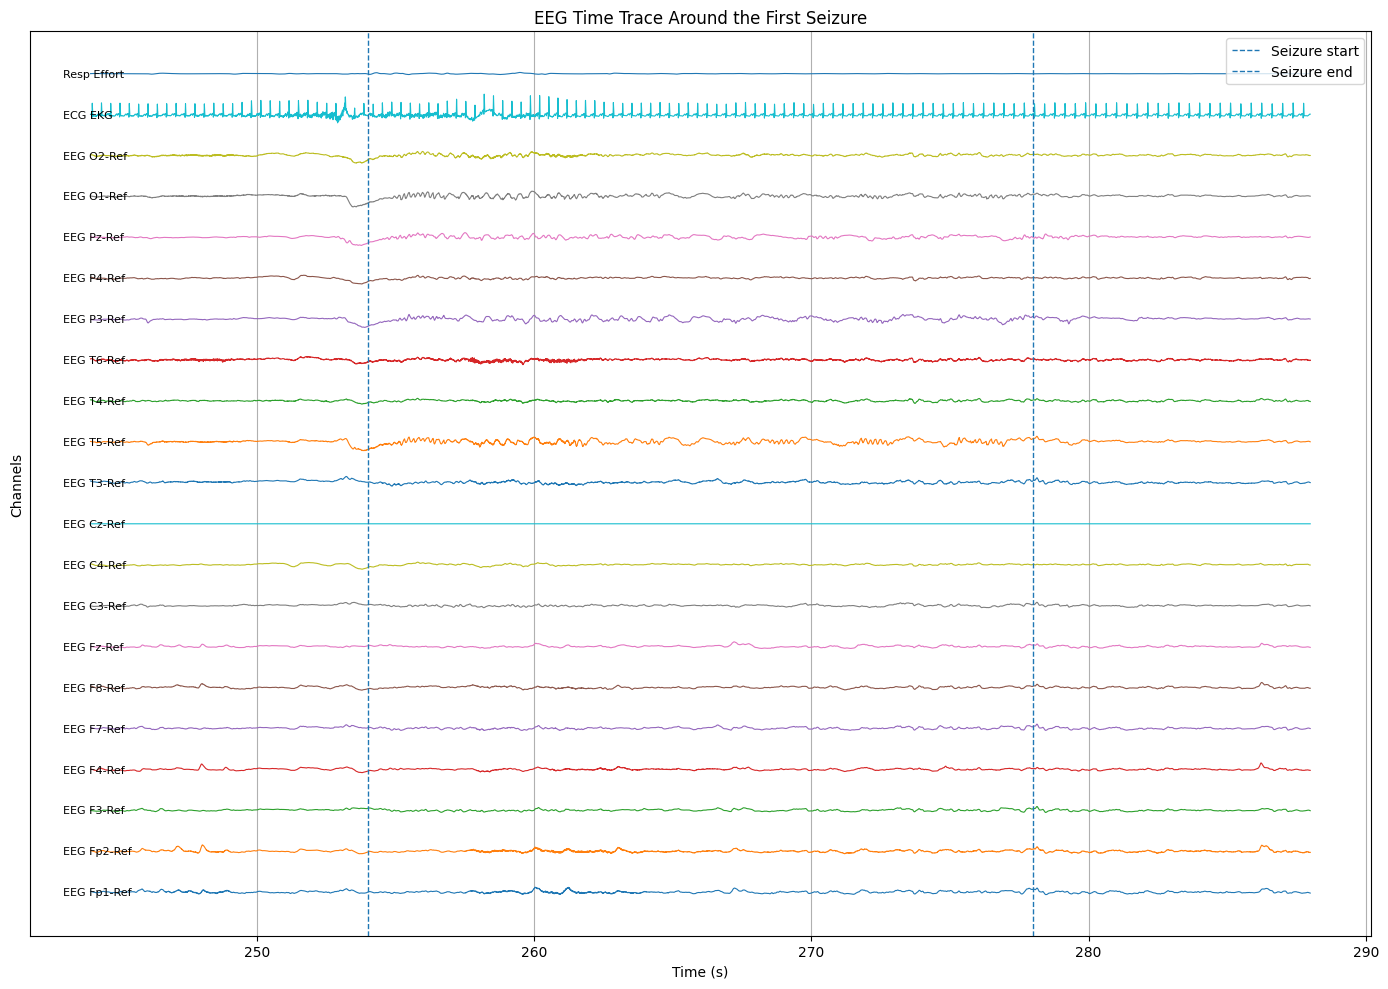

In [10]:
plt.figure(figsize=(14, 10))

offset = 0
step = np.max(np.abs(data)) * 2

for i in range(data.shape[0]):
    plt.plot(times, data[i] + offset, linewidth=0.8)
    plt.text(times[0] - 1, offset, raw.ch_names[i], fontsize=8, va="center")
    offset += step

# Mark seizure boundaries
plt.axvline(seizure_start, linestyle="--", linewidth=1, label="Seizure start")
plt.axvline(seizure_end, linestyle="--", linewidth=1, label="Seizure end")

plt.title("EEG Time Trace Around the First Seizure")
plt.xlabel("Time (s)")
plt.ylabel("Channels")
plt.yticks([])
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## Step 9 - Compute the average EEG signal across all channels

combine all EEG channels into a single signal.

This is done by:
1. extracting the EEG data from all channels
2. summing the signals sample by sample
3. dividing by the number of channels

This produces one averaged EEG signal representing the mean activity across all channels.

In [11]:
# Extract all EEG data
# Shape: (n_channels, n_samples)
all_data = raw.get_data()

print("EEG data shape:", all_data.shape)
print("Number of channels:", all_data.shape[0])
print("Number of samples:", all_data.shape[1])

EEG data shape: (21, 953856)
Number of channels: 21
Number of samples: 953856


## Step 10 - Create the averaged signal

Now we compute the mean of all EEG channels along the channel axis.

The result is a one-dimensional signal with length equal to the number of samples in the recording.

In [12]:
# Compute the average signal across all channels
avg_signal = np.mean(all_data, axis=0)

print("Averaged signal shape:", avg_signal.shape)
print("First 10 samples of the averaged signal:")
print(avg_signal[:10])

Averaged signal shape: (953856,)
First 10 samples of the averaged signal:
[8.31378643e-06 8.47313037e-06 8.47313037e-06 8.46516317e-06
 8.48906476e-06 8.50499916e-06 8.44922878e-06 8.42532719e-06
 8.40142560e-06 8.37752401e-06]


## Step 11 - Create a time axis for the averaged signal

To analyze or plot the averaged signal, we create a time axis in seconds.

In [13]:
# Create a time vector for the full recording
time = np.arange(len(avg_signal)) / raw.info["sfreq"]

print("Time axis length:", len(time))
print("Recording duration from time axis:", time[-1], "seconds")

Time axis length: 953856
Recording duration from time axis: 3725.99609375 seconds


## Step 12 - Plot the averaged signal around the first seizure

To verify that the averaging step worked correctly, we plot the averaged EEG signal around the first seizure interval.

This is only a visualization of the newly created signal.

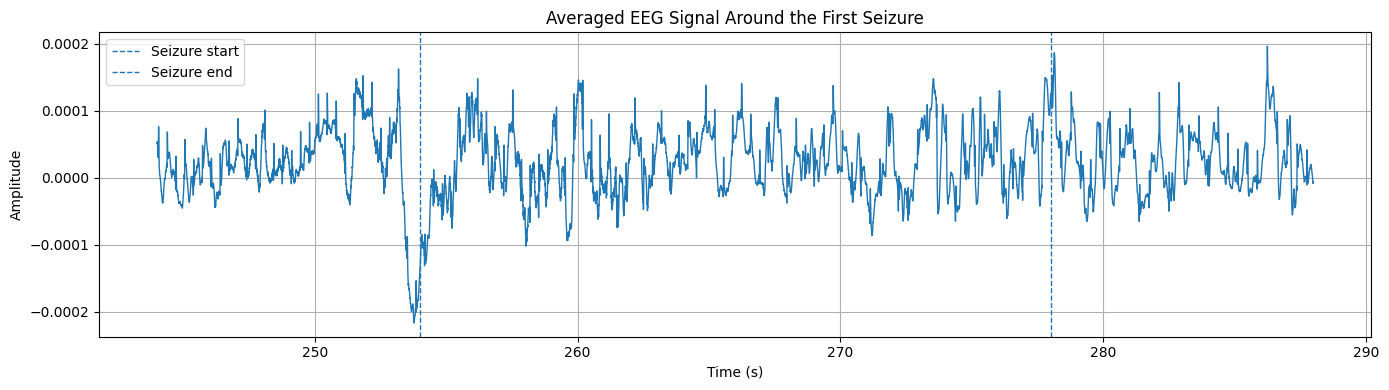

In [14]:
# Define the same plotting window used previously
pre_seconds = 10
post_seconds = 10

plot_start = max(0, seizure_start - pre_seconds)
plot_end = seizure_end + post_seconds

sfreq = raw.info["sfreq"]
start_sample = int(plot_start * sfreq)
end_sample = int(plot_end * sfreq)

plt.figure(figsize=(14, 4))
plt.plot(time[start_sample:end_sample], avg_signal[start_sample:end_sample], linewidth=1)
plt.axvline(seizure_start, linestyle="--", linewidth=1, label="Seizure start")
plt.axvline(seizure_end, linestyle="--", linewidth=1, label="Seizure end")
plt.title("Averaged EEG Signal Around the First Seizure")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## Step 13 - Remove frequencies above 60 Hz
we must remove all frequency components above 60 Hz from the averaged EEG signal.

This can be done by applying a **low-pass filter** with a cutoff frequency of 60 Hz.

The input signal is:
- the averaged EEG signal computed from all channels

The output signal will be:
- a filtered averaged EEG signal containing frequencies up to 60 Hz only

In [15]:
print("Sampling frequency:", sfreq, "Hz")
print("Low-pass cutoff frequency: 60 Hz")

Sampling frequency: 256.0 Hz
Low-pass cutoff frequency: 60 Hz


## Step 14 - Apply the low-pass filter

We now apply a low-pass filter at 60 Hz to the averaged signal.

This keeps the lower-frequency EEG components and suppresses higher-frequency activity above 60 Hz.

In [16]:
# Apply a low-pass filter at 60 Hz
filtered_signal = mne.filter.filter_data(
    avg_signal,
    sfreq=sfreq,
    l_freq=None,
    h_freq=60,
    verbose=False
)

print("Filtered signal shape:", filtered_signal.shape)
print("First 10 samples of the filtered signal:")
print(filtered_signal[:10])

Filtered signal shape: (953856,)
First 10 samples of the filtered signal:
[8.31378643e-06 8.44846887e-06 8.48838749e-06 8.47299833e-06
 8.48009679e-06 8.49385216e-06 8.46338494e-06 8.41194651e-06
 8.39675406e-06 8.39641035e-06]


## Step 15 - Compare the original averaged signal and the filtered signal

To verify that the filtering step worked correctly, we plot:

- the original averaged signal
- the filtered averaged signal

using the same time window around the first seizure.

In [17]:
# Use the same plotting interval around the first seizure
pre_seconds = 10
post_seconds = 10

plot_start = max(0, seizure_start - pre_seconds)
plot_end = seizure_end + post_seconds

start_sample = int(plot_start * sfreq)
end_sample = int(plot_end * sfreq)

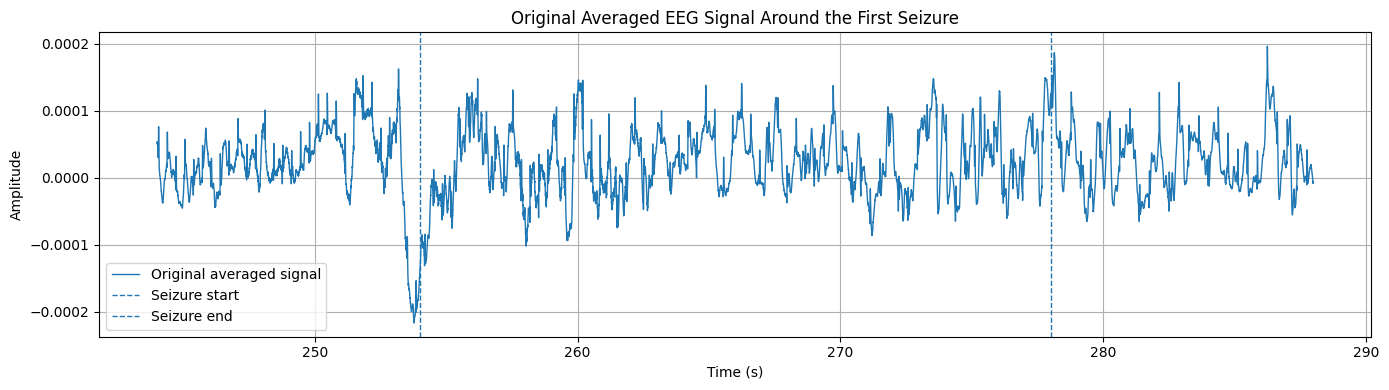

In [18]:
plt.figure(figsize=(14, 4))
plt.plot(
    time[start_sample:end_sample],
    avg_signal[start_sample:end_sample],
    linewidth=1,
    label="Original averaged signal"
)
plt.axvline(seizure_start, linestyle="--", linewidth=1, label="Seizure start")
plt.axvline(seizure_end, linestyle="--", linewidth=1, label="Seizure end")
plt.title("Original Averaged EEG Signal Around the First Seizure")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

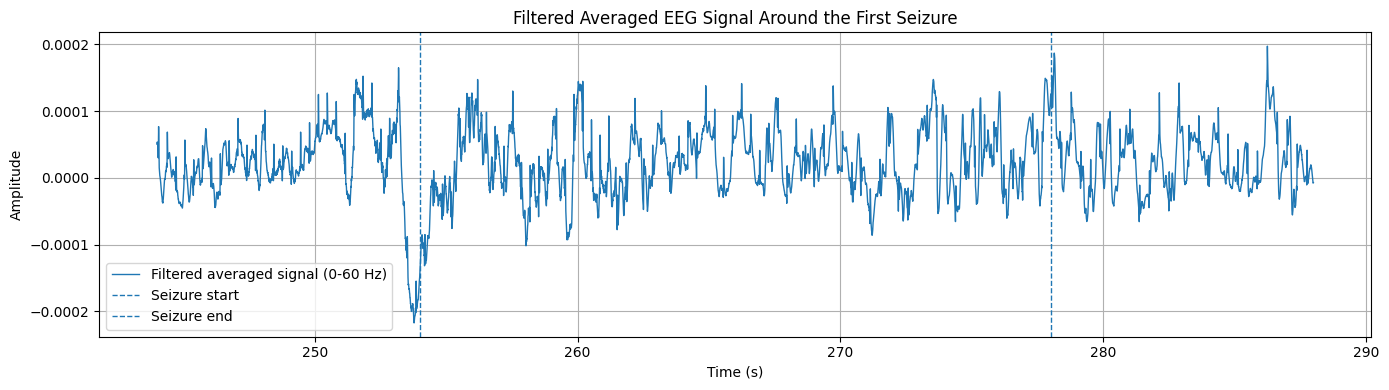

In [19]:
plt.figure(figsize=(14, 4))
plt.plot(
    time[start_sample:end_sample],
    filtered_signal[start_sample:end_sample],
    linewidth=1,
    label="Filtered averaged signal (0-60 Hz)"
)
plt.axvline(seizure_start, linestyle="--", linewidth=1, label="Seizure start")
plt.axvline(seizure_end, linestyle="--", linewidth=1, label="Seizure end")
plt.title("Filtered Averaged EEG Signal Around the First Seizure")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [20]:
# Save the filtered signal and its time axis for later use
filtered_time = time

print("Filtered signal is ready for the next step.")
print("Signal length:", len(filtered_signal))
print("Time axis length:", len(filtered_time))

Filtered signal is ready for the next step.
Signal length: 953856
Time axis length: 953856


## Step 16 - Plot the spectrogram of the filtered signal

 after filtering the averaged EEG signal, we must compute and plot its spectrogram.

A spectrogram shows how the signal power is distributed across:
- time
- frequency

This helps us observe how the frequency content changes during the recording.

In [21]:
from scipy import signal

## Step 17 - Compute the spectrogram

We compute the spectrogram of the filtered averaged EEG signal using the sampling frequency of the EEG recording.

Main parameters:
- `nperseg`: number of samples in each segment
- `noverlap`: number of overlapping samples between adjacent segments

These parameters control the time-frequency resolution of the spectrogram.

In [22]:
# Compute the spectrogram of the filtered signal
frequencies, times_spec, Sxx = signal.spectrogram(
    filtered_signal,
    fs=sfreq,
    nperseg=256,
    noverlap=128
)

print("Spectrogram computed successfully")
print("Frequencies shape:", frequencies.shape)
print("Time bins shape:", times_spec.shape)
print("Spectrogram matrix shape:", Sxx.shape)

Spectrogram computed successfully
Frequencies shape: (129,)
Time bins shape: (7451,)
Spectrogram matrix shape: (129, 7451)


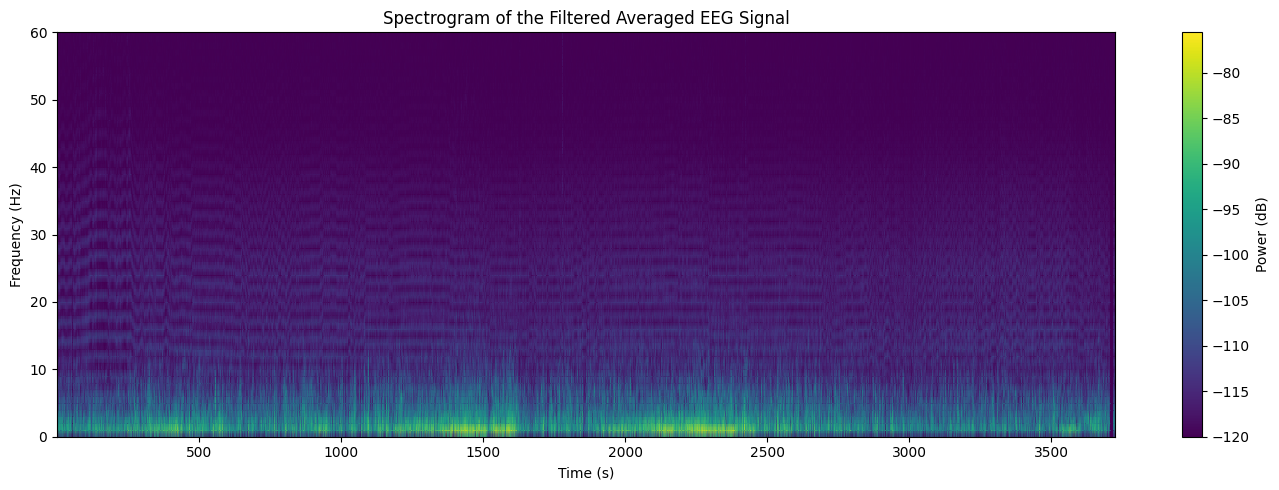

In [23]:
plt.figure(figsize=(14, 5))
plt.pcolormesh(
    times_spec,
    frequencies,
    10 * np.log10(Sxx + 1e-12),
    shading="gouraud"
)

plt.ylim(0, 60)
plt.title("Spectrogram of the Filtered Averaged EEG Signal")
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.colorbar(label="Power (dB)")
plt.tight_layout()
plt.show()

## Step 18 - Interpret the spectrogram

The spectrogram represents the time-frequency content of the filtered averaged EEG signal.

From this plot, we can examine:
- how signal power changes with time
- which frequency bands are more active
- whether seizure periods show stronger or different spectral patterns

In [24]:
print("Spectrogram step completed successfully.")

Spectrogram step completed successfully.


## Step 19 - Perform the wavelet transform

 the final step is to apply the wavelet transform to the filtered averaged EEG signal.

Unlike the spectrogram, the wavelet transform provides a time-frequency representation with multi-scale analysis.

This makes it useful for non-stationary signals such as EEG, where the frequency content may change over time.

In [25]:
import pywt

## Step 20 - Define the wavelet scales

To compute the continuous wavelet transform (CWT), we define a range of scales.

These scales control the frequency resolution of the transform.

We use the Morlet wavelet (`'morl'`), which is commonly used in EEG signal analysis.

In [26]:
# Define the wavelet scales
scales = np.arange(1, 128)

print("Number of scales:", len(scales))
print("First scale:", scales[0])
print("Last scale:", scales[-1])

Number of scales: 127
First scale: 1
Last scale: 127


## Step 21 - Compute the continuous wavelet transform

We now compute the continuous wavelet transform of the filtered averaged EEG signal.

Inputs:
- the filtered EEG signal
- the selected scales
- the Morlet wavelet
- the sampling period derived from the EEG sampling frequency

Outputs:
- wavelet coefficients
- corresponding pseudo-frequencies

In [27]:
# Compute the continuous wavelet transform
coefficients, freqs = pywt.cwt(
    filtered_signal,
    scales,
    'morl',
    sampling_period=1 / sfreq
)

print("Wavelet transform computed successfully")
print("Coefficients shape:", coefficients.shape)
print("Frequencies shape:", freqs.shape)

Wavelet transform computed successfully
Coefficients shape: (127, 953856)
Frequencies shape: (127,)


## Step 22 - Plot the scalogram

The scalogram is a visual representation of the wavelet transform.

It shows how the magnitude of the wavelet coefficients changes across:
- time
- frequency

To match the lab task, we display frequencies up to 60 Hz.

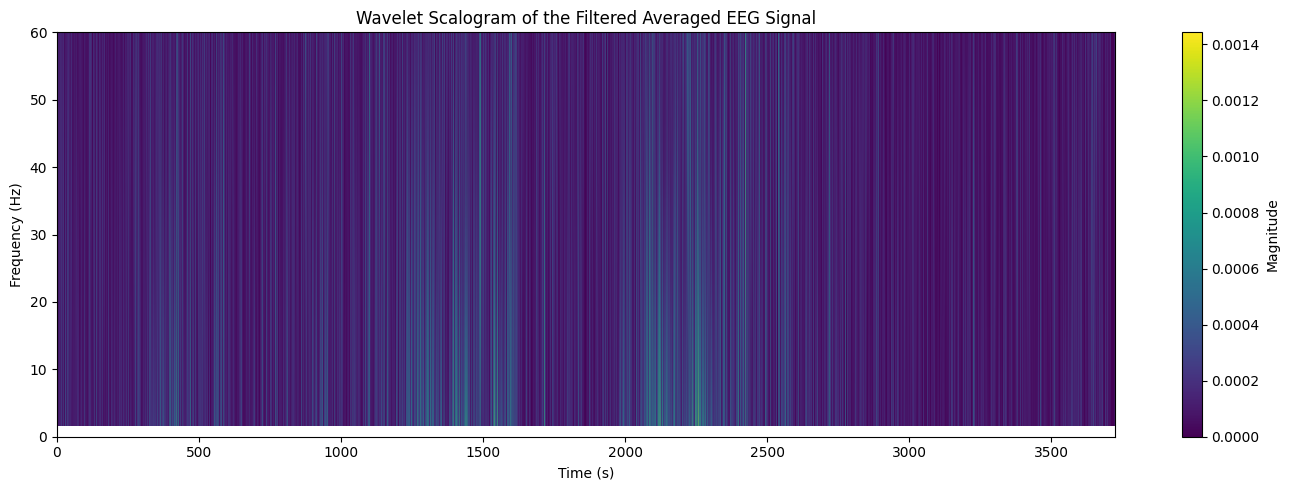

In [28]:
plt.figure(figsize=(14, 5))
plt.imshow(
    np.abs(coefficients),
    extent=[0, len(filtered_signal) / sfreq, freqs[-1], freqs[0]],
    aspect='auto'
)

plt.ylim(0, 60)
plt.title("Wavelet Scalogram of the Filtered Averaged EEG Signal")
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.colorbar(label="Magnitude")
plt.tight_layout()
plt.show()

## Final result

At this stage, the full required workflow has been completed:

1. loaded the EDF file
2. inspected the EEG recording
3. loaded the annotation files
4. detected seizure segments
5. plotted the EEG time trace around the first seizure
6. computed the averaged EEG signal across all channels
7. removed frequencies above 60 Hz
8. plotted the spectrogram of the filtered signal
9. performed the wavelet transform
10. plotted the scalogram

